In [3]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [4]:
df = pd.read_csv('../data/metrics/metrics.beta.csv')
df['beta'] = df['layout'].str.extract('IRIS-B([\d.]+)').astype(float)

In [5]:
data2name = {
	'scrna-embryo': 'scRNA-seq (Embryo)',
	'scrna-neuro': 'scRNA-seq (Neuro)',
	'lit-adrd': 'Literature (ADRD)',
	'lit-pd1': 'Literature (PD-1)',
	'meta-gut': 'Metagenomes',
}

datasets_ordered = list(data2name.keys())


In [10]:


def plot(df, metx, mety, labl):
    colors = ["Reds_r", "Blues_r", "Greens_r", "Purples_r", "Oranges_r", "Greys_r"]
    alg2line={'rep:tsne':'-', 'rep:umap':'--', 'pen:tsne':':', 'pen:umap':'-.'}
    metxl = metx#.lower()
    metyl = mety#.lower()

    # Plot the line with changing colors
    fig, axs = plt.subplots(3, 2, figsize=(10.5,15))
    for ax in axs.flat:
        ax.margins(x=0.2, y=0.2)
    plt.subplots_adjust(wspace=.25, hspace=.15)
    #sns.set_context("notebook", font_scale=.5)
    #sns.set_style("ticks")
    for k in range(len(datasets_ordered)+1):
        lines = []
        datasets_cur = datasets_ordered if k == 0 else [datasets_ordered[k-1]]
        ax = axs[k // 2, k % 2]
        for j, dat in enumerate(datasets_cur):#df['dataset'].unique()):
            dfreps = df[df['dataset']==dat][[metxl, metyl, 'beta']].groupby('beta')
            means = dfreps.mean().to_numpy()
            stds = dfreps.std().to_numpy()
            x, y = means[:,0], means[:,1]
            w, h = stds[:,0], stds[:,1]
            for i in range(len(x)-1):
                cmap = sns.color_palette(colors[j if k == 0 else k-1], as_cmap=True)
                line, = ax.plot(x[i:i+2], y[i:i+2],linestyle=alg2line['rep:tsne'],markersize=5,color=cmap(1-(i+1)/len(x)), label=data2name[dat],zorder=1)
                if i == int(len(x)/2):
                    lines.append(line)
            for i, val in enumerate(dfreps.groups.keys()):
                ellipse = patches.Ellipse((x[i], y[i]), width=w[i], height=h[i], angle=0, facecolor=cmap(1-(i+1)/len(x)),zorder=2, alpha=0.25)
                ax.add_patch(ellipse)
                if labl and k > 0:
                    ax.annotate('β='+str(val), (x[i], y[i]), xytext=(3, 3), textcoords='offset points', color=cmap(0.25))
                #plt.text(x[i]+.001, y[i]+.005, val)
        # Add labels and title
        if k // 2 == 1:
            ax.set_xlabel(metx)
        if k % 2 == 0:
            ax.set_ylabel(mety)
        if k >= 0:
            ax.legend(handles=lines)
    plt.savefig(f'fig-beta-results.pdf', dpi=300, bbox_inches='tight')

    plt.show()

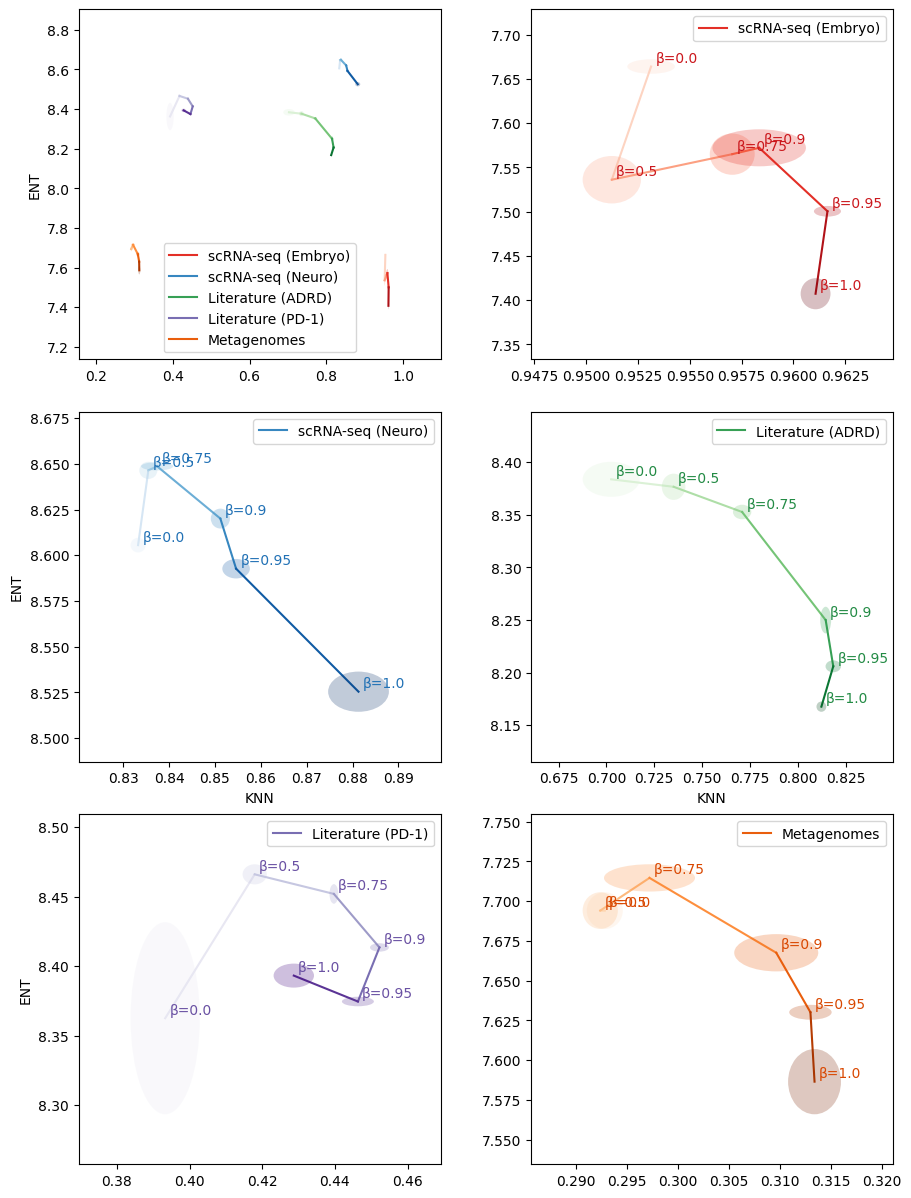

In [11]:
plot(df, 'KNN', 'ENT', True)